<a href="https://colab.research.google.com/github/CodingWithBilalkhan/Pytorch-Tutorials/blob/main/Iris_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [204]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [205]:
class Model(nn.Module):
  def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
    super().__init__()
    self.fc1 = nn.Linear(in_features, h1)
    self.fc2 = nn.Linear(h1, h2)
    self.out = nn.Linear(h2, out_features)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = F.relu(self.out(x))
    return x




In [206]:
torch.manual_seed(41)

model = Model()

In [207]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [208]:
url = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
data = pd.read_csv(url)
data.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [209]:
data['variety'] = data['variety'].replace('Setosa', 0.0)
data['variety'] = data['variety'].replace('Versicolor', 1.0)
data['variety'] = data['variety'].replace('Virginica', 2.0)
data.head()

/tmp/ipython-input-2095112689.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['variety'] = data['variety'].replace('Virginica', 2.0)


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0


In [210]:
X = data.drop('variety', axis=1)
y = data['variety']

In [211]:
X = X.values
y = y.values

In [212]:
from sklearn.model_selection import train_test_split

In [213]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

In [214]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [215]:
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [216]:
criterian = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [217]:
epochs = 100
losses = []

for i in range(epochs):
  y_pred = model.forward(X_train)

  # The output size of y_pred should match the target size for CrossEntropyLoss
  # No need to print sizes every epoch, so removing it.

  loss = criterian(y_pred, y_train)

  losses.append(loss.detach().numpy())

  if i%10 == 0:
    print(f'epoch: {i} loss: {loss.item()}') # Use .item() for scalar loss to avoid tensor wrapping

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

epoch: 0 loss: 1.125203251838684
epoch: 10 loss: 1.0097211599349976
epoch: 20 loss: 0.8516881465911865
epoch: 30 loss: 0.6555687189102173
epoch: 40 loss: 0.45029518008232117
epoch: 50 loss: 0.2718472480773926
epoch: 60 loss: 0.1553877890110016
epoch: 70 loss: 0.09336269646883011
epoch: 80 loss: 0.06463461369276047
epoch: 90 loss: 0.05066271126270294


Text(0, 0.5, 'Losses')

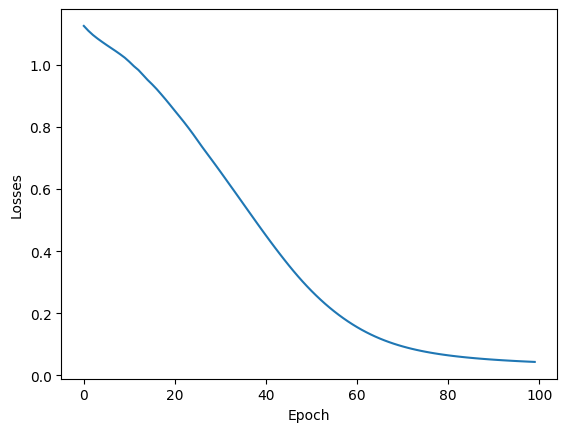

In [218]:
plt.plot(range(epochs), losses)
plt.xlabel("Epoch")
plt.ylabel("Losses")

In [219]:

with torch.no_grad():
  y_eval = model.forward(X_test)
  loss = criterian(y_eval, y_test)


In [221]:
correct = 0
with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)

    print(f'{i+1} - {str(y_val)} \t {y_test[i]} - {y_val.argmax().item()}')

    if(y_val.argmax().item() == y_test[i]):
      correct +=1
  print(f'Correct: {correct}')

1 - tensor([0.0000, 7.4447, 9.9152]) 	 2 - 2
2 - tensor([ 0.0000,  7.7042, 14.3743]) 	 2 - 2
3 - tensor([ 0.0000,  9.1280, 15.1753]) 	 2 - 2
4 - tensor([0.2102, 8.3280, 4.5364]) 	 1 - 1
5 - tensor([ 0.0000,  8.4035, 12.4779]) 	 2 - 2
6 - tensor([1.6255, 8.0527, 1.9799]) 	 1 - 1
7 - tensor([0.0000, 8.0659, 9.2757]) 	 2 - 2
8 - tensor([0.3294, 8.4105, 4.3070]) 	 1 - 1
9 - tensor([ 0.0000,  8.2367, 10.8423]) 	 2 - 2
10 - tensor([ 0.0000,  8.1941, 15.2505]) 	 2 - 2
11 - tensor([0.0000, 7.9806, 8.7350]) 	 2 - 2
12 - tensor([8.9715, 3.4637, 0.0000]) 	 0 - 0
13 - tensor([8.0554, 3.1741, 0.0000]) 	 0 - 0
14 - tensor([2.2377, 6.4805, 0.4353]) 	 1 - 1
15 - tensor([8.0202, 3.9148, 0.0000]) 	 0 - 0
16 - tensor([0.0000, 8.1254, 8.0101]) 	 2 - 1
17 - tensor([8.3626, 3.3009, 0.0000]) 	 0 - 0
18 - tensor([0.0000, 7.6349, 9.5548]) 	 1 - 2
19 - tensor([8.9383, 3.4532, 0.0000]) 	 0 - 0
20 - tensor([7.5003, 3.3025, 0.0000]) 	 0 - 0
21 - tensor([1.9760, 7.0980, 1.0766]) 	 1 - 1
22 - tensor([ 0.0000,  8.446

In [226]:
new_iris = torch.tensor([4.9,	3.0,	1.4,	0.2])
with torch.no_grad():
  pred = model(new_iris)
  print(pred)

tensor([8.5863, 3.3419, 0.0000])
